# 01 — EDA Raw: IBM AML HI-Small

**Author**: boutouileabdelkrim-pixel
**Date**: 2026-10-07
**Goal**: Understand structure, types, missing values, class imbalance,
temporal patterns and duplicates before any cleaning.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Resolve project root robustly (works both from project root and from notebooks/)
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW = PROJECT_ROOT / "data" / "raw"
REPORTS = PROJECT_ROOT / "reports"
REPORTS.mkdir(parents=True, exist_ok=True)

TRANS_PATH = RAW / "HI-Small_Trans.csv"
ACC_PATH = RAW / "HI-Small_accounts.csv"

plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["figure.dpi"] = 100

print("Project root:", PROJECT_ROOT)
print("Trans file  :", TRANS_PATH.exists(), f"({TRANS_PATH.stat().st_size / 1e6:.1f} MB)")
print("Acc file    :", ACC_PATH.exists(), f"({ACC_PATH.stat().st_size / 1e6:.1f} MB)")

Project root: /home/loranos/projects/aml-network-intelligence
Trans file  : True (475.7 MB)
Acc file    : True (34.1 MB)


## 1. Load data

We load with the pyarrow backend for speed and clean dtype detection.
Note: the raw CSV has a **duplicated** `Account` column, pandas will
auto-rename the second one to `Account.1`.

In [2]:
df = pd.read_csv(
    TRANS_PATH,
    dtype_backend="pyarrow",
    parse_dates=["Timestamp"],
)
print("Shape:", df.shape)
print("\nColumns:")
for c in df.columns:
    print("  -", c)

Shape: (5078345, 11)

Columns:
  - Timestamp
  - From Bank
  - Account
  - To Bank
  - Account.1
  - Amount Received
  - Receiving Currency
  - Amount Paid
  - Payment Currency
  - Payment Format
  - Is Laundering


In [3]:
df.head()

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022-09-01 00:20:00,10,8000EBD30,10,8000EBD30,3697.34,US Dollar,3697.34,US Dollar,Reinvestment,0
1,2022-09-01 00:20:00,3208,8000F4580,1,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0
2,2022-09-01 00:00:00,3209,8000F4670,3209,8000F4670,14675.57,US Dollar,14675.57,US Dollar,Reinvestment,0
3,2022-09-01 00:02:00,12,8000F5030,12,8000F5030,2806.97,US Dollar,2806.97,US Dollar,Reinvestment,0
4,2022-09-01 00:06:00,10,8000F5200,10,8000F5200,36682.97,US Dollar,36682.97,US Dollar,Reinvestment,0


In [4]:
df.dtypes

Timestamp              datetime64[ns]
From Bank              int64[pyarrow]
Account               string[pyarrow]
To Bank                int64[pyarrow]
Account.1             string[pyarrow]
Amount Received       double[pyarrow]
Receiving Currency    string[pyarrow]
Amount Paid           double[pyarrow]
Payment Currency      string[pyarrow]
Payment Format        string[pyarrow]
Is Laundering          int64[pyarrow]
dtype: object

## 2. Missing values

In [5]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(4)
missing_df = pd.DataFrame({"missing": missing, "pct": missing_pct})
missing_df

,missing,pct
Timestamp,0,0.0
From Bank,0,0.0
Account,0,0.0
To Bank,0,0.0
Account.1,0,0.0
Amount Received,0,0.0
Receiving Currency,0,0.0
Amount Paid,0,0.0
Payment Currency,0,0.0
Payment Format,0,0.0


## 3. Target distribution (class imbalance)

In [6]:
target_counts = df["Is Laundering"].value_counts().sort_index()
target_pct = df["Is Laundering"].value_counts(normalize=True).sort_index() * 100

print("Counts:")
print(target_counts)
print("\nPercentage:")
print(target_pct.round(4))

Counts:
Is Laundering
0    5073168
1       5177
Name: count, dtype: int64[pyarrow]

Percentage:
Is Laundering
0    99.8981
1     0.1019
Name: proportion, dtype: double[pyarrow]


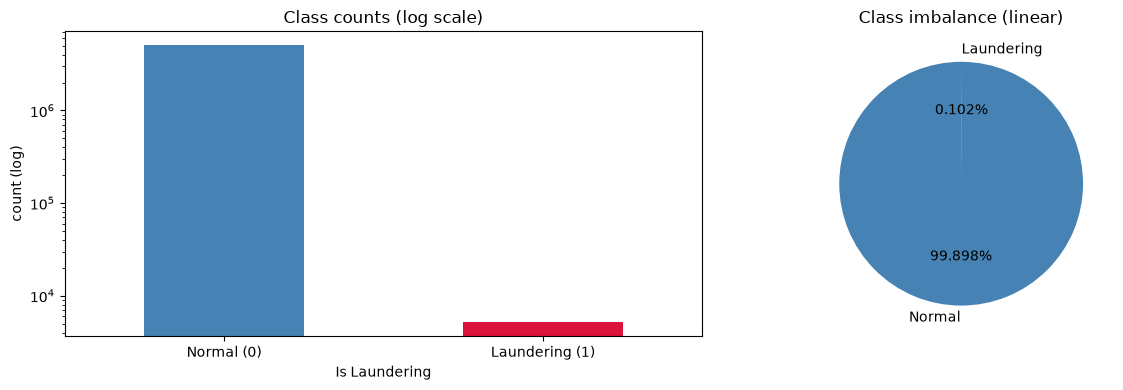

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

target_counts.plot(kind="bar", ax=axes[0], color=["steelblue", "crimson"])
axes[0].set_title("Class counts (log scale)")
axes[0].set_yscale("log")
axes[0].set_xticklabels(["Normal (0)", "Laundering (1)"], rotation=0)
axes[0].set_ylabel("count (log)")

axes[1].pie(
    target_counts,
    labels=["Normal", "Laundering"],
    autopct="%1.3f%%",
    colors=["steelblue", "crimson"],
    startangle=90,
)
axes[1].set_title("Class imbalance (linear)")
plt.tight_layout()
plt.savefig(REPORTS / "target_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

## 4. Amount distributions

In [8]:
print("=== Amount Paid ===")
print(df["Amount Paid"].describe().astype(float))

print("\n=== Amount Received ===")
print(df["Amount Received"].describe().astype(float))

=== Amount Paid ===


count    5.078345e+06
mean     4.509273e+06
std      8.697728e+08
min      1.000000e-06
25%      1.844800e+02
50%      1.414540e+03
75%      1.229784e+04
max      1.046302e+12
Name: Amount Paid, dtype: float64

=== Amount Received ===
count    5.078345e+06
mean     5.988726e+06
std      1.037183e+09
min      1.000000e-06
25%      1.833700e+02
50%      1.411010e+03
75%      1.234627e+04
max      1.046302e+12
Name: Amount Received, dtype: float64


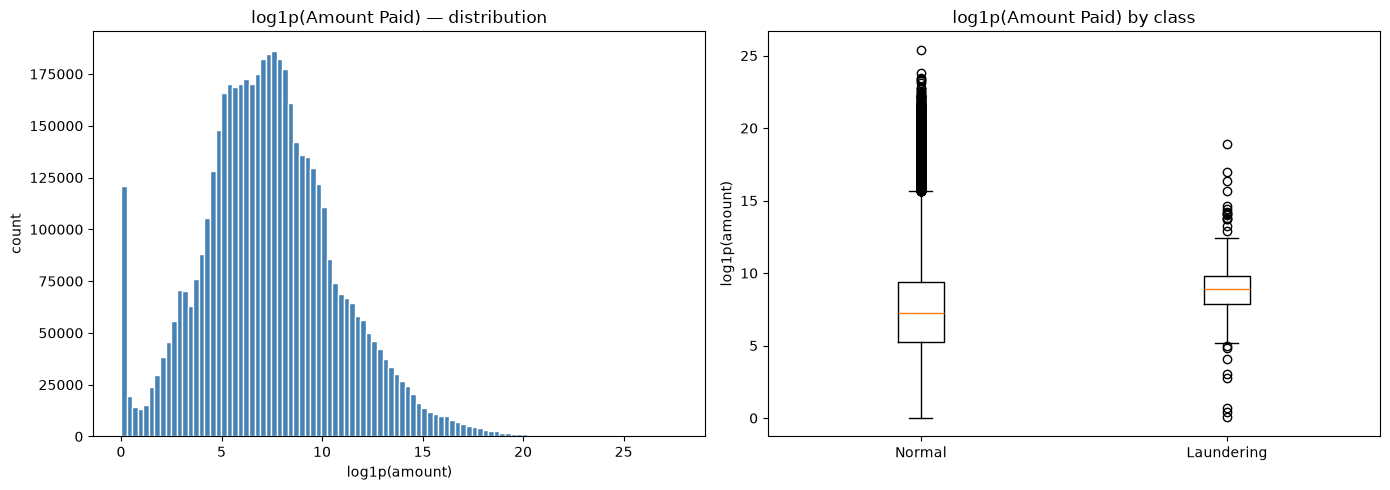

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Log-scale histogram
axes[0].hist(
    np.log1p(df["Amount Paid"].astype(float).dropna()),
    bins=100,
    color="steelblue",
    edgecolor="white",
)
axes[0].set_title("log1p(Amount Paid) — distribution")
axes[0].set_xlabel("log1p(amount)")
axes[0].set_ylabel("count")

# Boxplot by class (sample for speed)
df_sample = df.sample(n=min(200_000, len(df)), random_state=42)
amounts_by_target = [
    np.log1p(df_sample[df_sample["Is Laundering"] == 0]["Amount Paid"].astype(float).dropna()),
    np.log1p(df_sample[df_sample["Is Laundering"] == 1]["Amount Paid"].astype(float).dropna()),
]
axes[1].boxplot(amounts_by_target, tick_labels=["Normal", "Laundering"])
axes[1].set_title("log1p(Amount Paid) by class")
axes[1].set_ylabel("log1p(amount)")
plt.tight_layout()
plt.savefig(REPORTS / "amount_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

## 5. Categorical distributions

In [10]:
for col in ["Payment Format", "Receiving Currency", "Payment Currency"]:
    print(f"\n=== {col} ===")
    print(df[col].value_counts().head(10))


=== Payment Format ===
Payment Format
Cheque          1864331
Credit Card     1323324
ACH              600797
Cash             490891
Reinvestment     481056
Wire             171855
Bitcoin          146091
Name: count, dtype: int64[pyarrow]

=== Receiving Currency ===


Receiving Currency
US Dollar      1879341
Euro           1172017
Swiss Franc     237884
Yuan            206551
Shekel          194988
Rupee           192065
UK Pound        181255
Ruble           157361
Yen             156319
Bitcoin         148151
Name: count, dtype: int64[pyarrow]

=== Payment Currency ===
Payment Currency
US Dollar      1895172
Euro           1168297
Swiss Franc     234860
Yuan            213752
Shekel          192184
Rupee           190202
UK Pound        180738
Yen             155209
Ruble           155178
Bitcoin         146066
Name: count, dtype: int64[pyarrow]


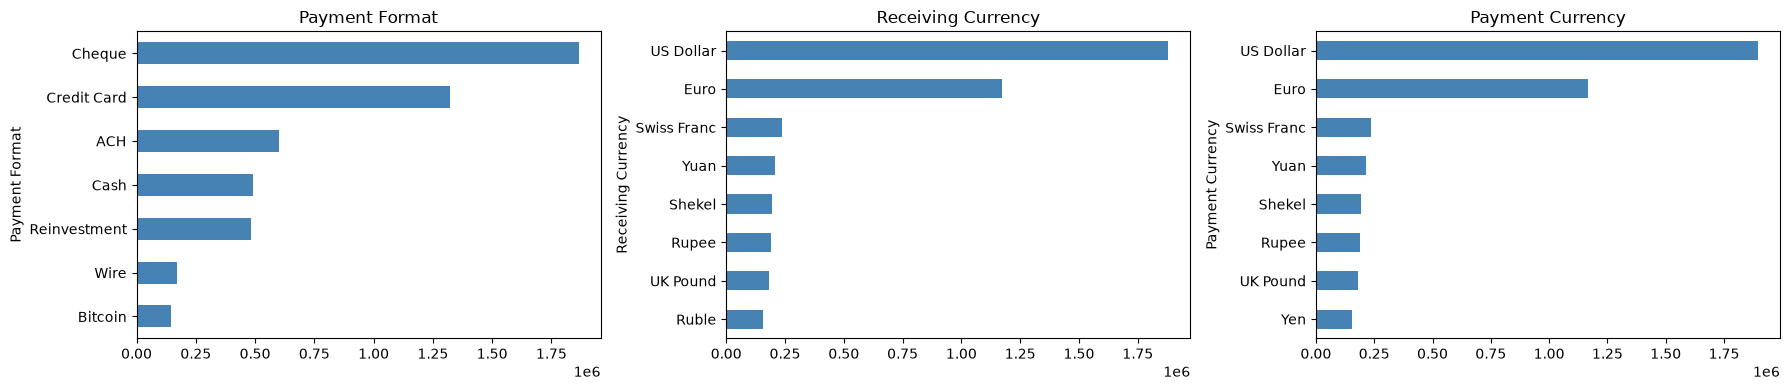

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, col in zip(axes, ["Payment Format", "Receiving Currency", "Payment Currency"]):
    df[col].value_counts().head(8).plot(kind="barh", ax=ax, color="steelblue")
    ax.set_title(col)
    ax.invert_yaxis()
plt.tight_layout()
plt.savefig(REPORTS / "categoricals.png", dpi=120, bbox_inches="tight")
plt.show()

## 6. Temporal analysis

Date range: 2022-09-01 00:00:00 → 2022-09-18 16:18:00
Duration  : 17 days


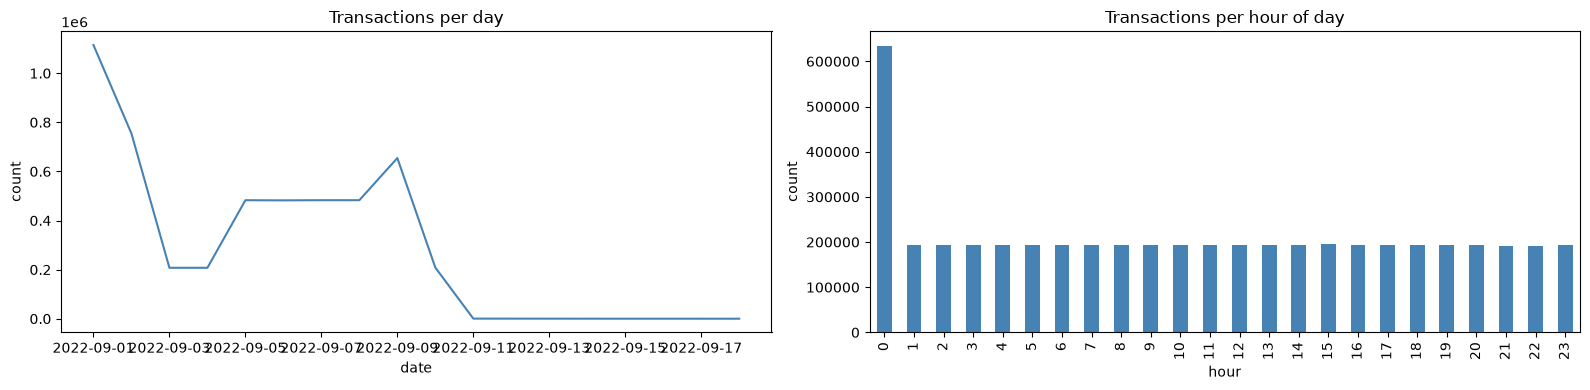

In [12]:
df["date"] = df["Timestamp"].dt.date
df["hour"] = df["Timestamp"].dt.hour

print("Date range:", df["Timestamp"].min(), "→", df["Timestamp"].max())
print("Duration  :", (df["Timestamp"].max() - df["Timestamp"].min()).days, "days")

daily = df.groupby("date").size()
hourly = df.groupby("hour").size()

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
daily.plot(ax=axes[0], color="steelblue")
axes[0].set_title("Transactions per day")
axes[0].set_xlabel("date")
axes[0].set_ylabel("count")

hourly.plot(kind="bar", ax=axes[1], color="steelblue")
axes[1].set_title("Transactions per hour of day")
axes[1].set_xlabel("hour")
axes[1].set_ylabel("count")
plt.tight_layout()
plt.savefig(REPORTS / "temporal.png", dpi=120, bbox_inches="tight")
plt.show()

## 7. Duplicates & sanity checks

In [13]:
print("Duplicated full rows :", df.duplicated().sum())

from_acc = df["Account"].astype(str)
to_acc = df["Account.1"].astype(str)
self_loops = (from_acc == to_acc).sum()
print("Self-loop transactions (from == to) :", self_loops)

print("\nUnique source accounts      :", df["Account"].nunique())
print("Unique destination accounts :", df["Account.1"].nunique())
print("Unique banks (from)         :", df["From Bank"].nunique())
print("Unique banks (to)           :", df["To Bank"].nunique())
print("Unique payment formats      :", df["Payment Format"].nunique())
print("Unique currencies           :", df["Payment Currency"].nunique())

Duplicated full rows : 9


Self-loop transactions (from == to) : 591212



Unique source accounts      : 496995


Unique destination accounts : 420636
Unique banks (from)         : 30470
Unique banks (to)           : 15811
Unique payment formats      : 7


Unique currencies           : 15


## 8. Key insights (auto-generated)

In [14]:
insights = {
    "total_transactions": int(len(df)),
    "laundering_count": int((df["Is Laundering"] == 1).sum()),
    "laundering_rate_pct": float((df["Is Laundering"] == 1).mean() * 100),
    "date_range_days": int((df["Timestamp"].max() - df["Timestamp"].min()).days),
    "unique_source_accounts": int(df["Account"].nunique()),
    "unique_dest_accounts": int(df["Account.1"].nunique()),
    "unique_banks": int(max(df["From Bank"].nunique(), df["To Bank"].nunique())),
    "self_loop_count": int(self_loops),
    "duplicate_rows": int(df.duplicated().sum()),
}
for k, v in insights.items():
    print(f"{k:30s}: {v}")

total_transactions            : 5078345
laundering_count              : 5177
laundering_rate_pct           : 0.10194266045335636
date_range_days               : 17
unique_source_accounts        : 496995
unique_dest_accounts          : 420636
unique_banks                  : 30470
self_loop_count               : 591212
duplicate_rows                : 9
